In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

In [2]:
hf_token=os.getenv("HF_TOKEN")

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [17]:
from typing import Annotated, List, TypedDict
from pydantic import BaseModel, Field
import operator
import json
from IPython.display import Image, display
import re
from typing import Literal
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_core.messages import SystemMessage, HumanMessage



In [11]:
#graph state

class State(TypedDict):
    joke:str
    topic:str
    feedback:str
    funny_or_not:str

#schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade:Literal["funny","not funny"]=Field(description="Decide if the joe is funny or not")
    feedback:str=Field(description="If the joke is not funny,provide feedback on how to improve it")

#augment the LLM with the schema for structured output
evaluator=llm.with_structured_output(Feedback)
    

In [13]:
def llm_call_generator(state:State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg=llm.invoke(f"Write a joke about {state['topic']} but take into account the feedback : {state['feedback']}")

    else:
        msg=llm.invoke(f"Write a joke about topic {state['topic']}")

    return {'joke':msg.content}

In [14]:
def llm_call_evaluator(state:State):
    """LLM evaluates the joke"""
    grade=evaluator.invoke(f"Grade the joke{state['joke']}")
    return {"funny_or_not":grade.grade,"feedback":grade.feedback}

#conditional edge func to routr back to joke generator or end on based upon feedback

def route_joke(state:State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"]=="funny":
        return "Accepted"
    elif state["funny_or_not"]=="not funny":
        return "Rejected+Feedback"

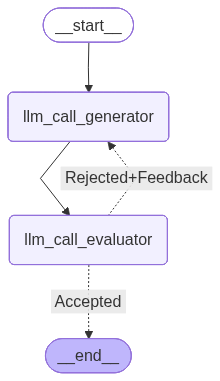

In [19]:
#build overflow

optimizer_builder=StateGraph(State)

#add mode
optimizer_builder.add_node("llm_call_generator",llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator",llm_call_evaluator)

#add edges to connect nodes
optimizer_builder.add_edge(START,"llm_call_generator")
optimizer_builder.add_edge("llm_call_generator","llm_call_evaluator")
optimizer_builder.add_conditional_edges("llm_call_evaluator",
                                        route_joke,
                                        {
                                            #name returned by route joke: name of next node to visist
                                            "Accepted":END,
                                            "Rejected+Feedback":"llm_call_generator"
                                        }
                                       )

#compile the flow
optimizer_workflow=optimizer_builder.compile()

#show the workflow
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

In [20]:
#invoke

state=optimizer_workflow.invoke({"topic":"cats"})
print(state['joke'])

Why did the cat sit on the computer?

To keep an eye on the mouse!
